# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

### Who: 
Healthcare leaders and public health professionals who are interested in identifying factors associated with diabetes risk.
### What: 
I want them to understand which health and lifestyle factors appear to be most strongly associated with prediabetes and diabetes so they can better recognize areas for prevention and education.
### How: 
I will use the Diabetes Health Indicators dataset to examine variables such as BMI, high blood pressure, high cholesterol, smoking, physical activity, and access to healthcare, and use clear visualizations to show how these factors differ across people with no diabetes, prediabetes, and diabetes.

# 3. Homework - work with your chosen project datasets this semester

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

df = pd.read_csv("data/diabetes_012_health_indicators_BRFSS2015.csv")

df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

### Dataset Summary

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

In [3]:
# Descriptive Statistics
df.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


#### The dataset contains 253,680 observations across 22 variables. Many of the variables are binary health indicators coded as 0 and 1, while some variables such as age, education, income, and diabetes status are represented using numeric category codes. BMI is a continuous variable with an average of about 28.38 and a median of 27. The descriptive statistics also show that all variables contain the same number of observations, which is consistent with the earlier info() output showing no missing values.

### Duplicate Rows

In [4]:
df.duplicated().sum()

np.int64(23899)

#### The dataset contains 23,899 duplicate rows. However, because this dataset consists of survey responses and does not include a unique respondent identifier, identical rows may represent different individuals with the same combination of responses. Therefore, I will review the duplicate rows carefully before deciding whether they should be removed.

In [5]:
duplicates = df[df.duplicated(keep=False)]

duplicates.head(10)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
5,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,2.0,0.0,1.0,10.0,6.0,8.0
25,0.0,0.0,0.0,1.0,32.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,5.0,6.0,8.0
29,0.0,0.0,1.0,1.0,31.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
44,0.0,0.0,1.0,1.0,31.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0
52,2.0,1.0,1.0,1.0,27.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,0.0,30.0,1.0,0.0,10.0,4.0,5.0
53,0.0,0.0,0.0,1.0,31.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,10.0,5.0,6.0
57,0.0,0.0,1.0,1.0,24.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,10.0,6.0,8.0
70,0.0,1.0,1.0,1.0,27.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,12.0,5.0,5.0
80,0.0,1.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,7.0,6.0,8.0
113,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,8.0,6.0,8.0


In [6]:
duplicates.shape

(35086, 22)

#### The dataset contains 23,899 duplicate rows, and 35,086 observations are part of a duplicated response pattern. However, the dataset does not contain a unique respondent identifier, and multiple survey participants may legitimately have the same combination of health and demographic responses. Therefore, I would not automatically remove these duplicate rows because doing so could remove valid observations.

#### There is no unique ID column in this dataset, so duplicate values within individual columns are expected. Variables such as BMI, age category, diabetes status, and health indicators will naturally contain repeated values across different respondents. Therefore, duplicate values within these columns are not considered inappropriate.

### Mean, Median, and Mode

In [7]:
summary_stats = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Mode": df.mode().iloc[0]
})

summary_stats

,Mean,Median,Mode
Diabetes_012,0.296921,0.0,0.0
HighBP,0.429001,0.0,0.0
HighChol,0.424121,0.0,0.0
CholCheck,0.962670,1.0,1.0
BMI,28.382364,27.0,27.0
Smoker,0.443169,0.0,0.0
Stroke,0.040571,0.0,0.0
HeartDiseaseorAttack,0.094186,0.0,0.0
PhysActivity,0.756544,1.0,1.0
Fruits,0.634256,1.0,1.0


#### The mean, median, and mode were calculated for all 22 variables. For continuous variables such as BMI, these statistics provide useful information about the center of the distribution. BMI had a mean of 28.38 and both a median and mode of 27. Many of the remaining variables are binary indicators or coded categories, so their medians and modes are generally more interpretable than their means. For example, age, education, income, and diabetes status are represented by numeric category codes rather than true continuous measurements.

In [16]:
# Example of one-hot encoding categorical variables
encoded_example = pd.get_dummies(
    df[["Education", "Income"]],
    columns=["Education", "Income"],
    prefix=["Education", "Income"]
)

encoded_example.head()

,Education_1.0,Education_2.0,Education_3.0,Education_4.0,Education_5.0,Education_6.0,Income_1.0,Income_2.0,Income_3.0,Income_4.0,Income_5.0,Income_6.0,Income_7.0,Income_8.0
0,False,False,False,True,False,False,False,False,True,False,False,False,False,False
1,False,False,False,False,False,True,True,False,False,False,False,False,False,False
2,False,False,False,True,False,False,False,False,False,False,False,False,False,True
3,False,False,True,False,False,False,False,False,False,False,False,True,False,False
4,False,False,False,False,True,False,False,False,False,True,False,False,False,False


Some variables in this dataset, such as education and income, are categorical even though they are represented with numeric codes. I demonstrated one-hot encoding on these variables using pd.get_dummies(). Most binary variables are already encoded as 0 and 1, so they do not need additional encoding at this stage. Whether one-hot encoding is necessary for other variables will depend on the machine learning model used later.

### Missing or Null Values

In [8]:
# missing values by column
df.isnull().sum()

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [9]:
# missing value in entire dataset
df.isnull().sum().sum()

np.int64(0)

#### The dataset does not contain any missing or null values. Every column returned a missing-value count of 0, so no imputation, row removal, or other missing-data treatment is needed.

In [ ]:
# unique value in each column
for col in df.columns:
    print(col, df[col].unique()[:20])

Diabetes_012 [0. 2. 1.]
HighBP [1. 0.]
HighChol [1. 0.]
CholCheck [1. 0.]
BMI [40. 25. 28. 27. 24. 30. 34. 26. 33. 21. 23. 22. 38. 32. 37. 31. 29. 20.
 35. 45.]
Smoker [1. 0.]
Stroke [0. 1.]
HeartDiseaseorAttack [0. 1.]
PhysActivity [0. 1.]
Fruits [0. 1.]
Veggies [1. 0.]
HvyAlcoholConsump [0. 1.]
AnyHealthcare [1. 0.]
NoDocbcCost [0. 1.]
GenHlth [5. 3. 2. 4. 1.]
MentHlth [18.  0. 30.  3.  5. 15. 10.  6. 20.  2. 25.  1.  4.  7.  8. 21. 14. 26.
 29. 16.]
PhysHlth [15.  0. 30.  2. 14. 28.  7. 20.  3. 10.  1.  5. 17.  4. 19.  6. 12. 25.
 27. 21.]
DiffWalk [1. 0.]
Sex [0. 1.]
Age [ 9.  7. 11. 10.  8. 13.  4.  6.  2. 12.  5.  1.  3.]
Education [4. 6. 3. 5. 2. 1.]
Income [3. 1. 8. 6. 4. 7. 2. 5.]


In [12]:
# uniqu value for larger-range variables
df[["BMI", "MentHlth", "PhysHlth", "Age", "Education", "Income"]].agg(["min", "max"])

,BMI,MentHlth,PhysHlth,Age,Education,Income
min,12.0,0.0,0.0,1.0,1.0,1.0
max,98.0,30.0,30.0,13.0,6.0,8.0


#### I checked the unique values and minimum/maximum ranges for the variables to look for inconsistent or impossible data. The binary variables were coded only as 0 and 1, diabetes status was coded as 0, 1, or 2, and the categorical variables stayed within their expected ranges. Mental and physical health days ranged from 0 to 30, while age, education, and income also stayed within their defined category ranges. I did not identify any obvious inconsistent or impossible values that would require correction.

In [14]:
df["Diabetes_012"].value_counts()

Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64

In [15]:
df["Diabetes_012"].value_counts(normalize=True) * 100

Diabetes_012
0.0    84.241170
2.0    13.933302
1.0     1.825528
Name: proportion, dtype: float64

#### The diabetes outcome variable is highly imbalanced. About 84.24% of respondents are in the no-diabetes category, 13.93% are in the diabetes category, and only 1.83% are in the prediabetes category. This imbalance is important because a future predictive model could become biased toward the majority class. If this dataset is used for machine learning later, I would need to consider methods such as class weighting, resampling, or using evaluation metrics that account for class imbalance.

### Conclusion
#### Overall, the dataset is usable for this project. It contains 253,680 observations and 22 variables, with no missing values and no obvious inconsistent or impossible values. Although there are duplicate response patterns, I would not automatically remove them because the dataset does not include a unique respondent identifier and different participants may have identical responses. Most categorical variables are already numerically encoded, so additional encoding is not necessary for this initial preprocessing step. The main issue identified is class imbalance in the diabetes outcome variable, particularly the small prediabetes group, which would need to be considered in future predictive modeling.

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough. If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

### Recreating a Storytelling With Data Graph

I chose to recreate Figure 0.5 from the Introduction of Storytelling With Data. The graph compares student attitudes toward science before and after a pilot program. I used Matplotlib to create a rough grouped bar chart with the same general structure.

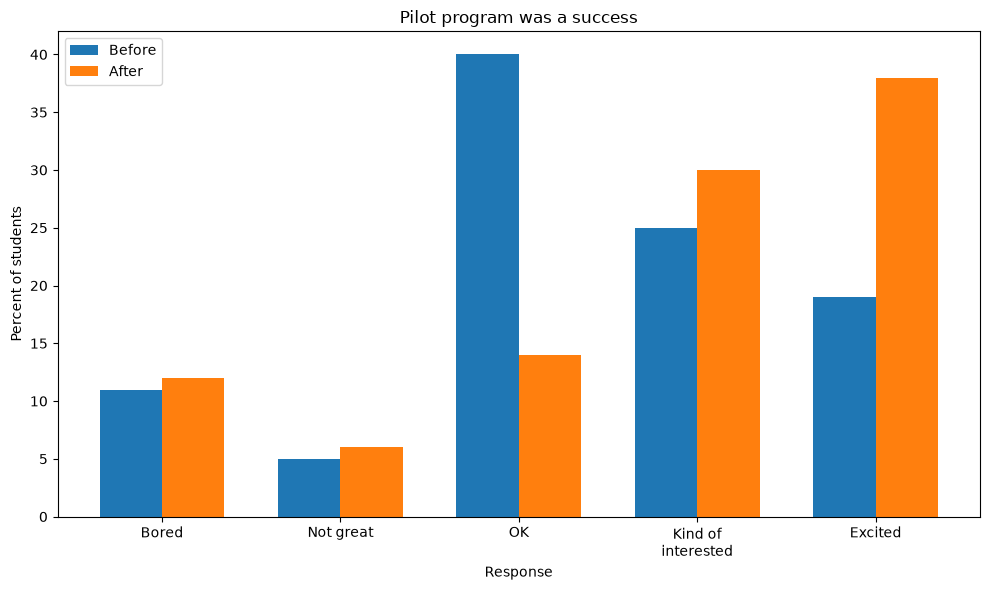

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Categories and values from the example graph
categories = ["Bored", "Not great", "OK", "Kind of\ninterested", "Excited"]

before = [11, 5, 40, 25, 19]
after = [12, 6, 14, 30, 38]

x = np.arange(len(categories))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, before, width, label="Before")
plt.bar(x + width/2, after, width, label="After")

plt.title("Pilot program was a success")
plt.ylabel("Percent of students")
plt.xlabel("Response")
plt.xticks(x, categories)

plt.legend()

plt.tight_layout()
plt.show()

#### I recreated the graph using a grouped bar chart in Matplotlib. I focused on reproducing the overall structure rather than every design detail from the original. The grouped bars make it easy to compare how student responses changed before and after the program, especially the decrease in “OK” responses and the increase in “Kind of interested” and “Excited” responses.